# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


Let's find the time to fall to the bottom of the shaft analytically first, taking gravity to be roughly constant (a good approximation given $4\text{ km}<<R_{Earth}$:)
$$y''=-g\Rightarrow |y|=\frac{1}{2}gt^2$$
(assuming no initial velocity and calling the initial height 0.)
$$t=\sqrt{\frac{2y_0}{g}}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

G = 6.6743e-11
M_earth = 5.972e24
R_earth = 6.3781e6
g_0 = 9.81
M_moon = 7.35e22
R_moon = 1.7381e6

y_0 = 4e3
print(f"The test mass would fall for {np.sqrt(2*y_0/g_0)} seconds.")

The test mass would fall for 28.55686245854129 seconds.


Making the substitution $\frac{dy}{dt}=v(t)$, we have
$$\begin{cases}
\frac{dv}{dt}=-g+\alpha v^\gamma \\
\frac{dy}{dt}=v
\end{cases}$$

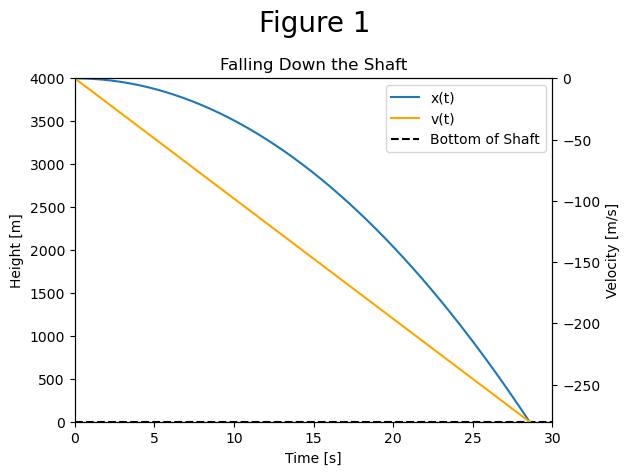

According to solve_ivp, the mass hits the bottom of the shaft at t = 28.557 seconds.
We compare this to the theoretical prediction t = 28.557 seconds.


In [2]:
def shaft_system(t, z, gamma, alpha=0):
    y, v = z
    dvdt = -g_0+alpha*v**gamma
    dydt = v
    return [dydt, dvdt]

def hit_ground(t, z, gamma, alpha=0):
    y, v = z
    return y

z0 = [4e3,0]
t_span = (0,1.5*np.sqrt(2*y_0/g_0))
t_eval = np.linspace(t_span[0],t_span[1], 300)

sol = solve_ivp(shaft_system, t_span=t_span, y0=z0, t_eval=t_eval, events=hit_ground, args=(0,0))

fig1, ax = plt.subplots()
ax2 = ax.twinx()
l1, = ax.plot(sol.t, sol.y[0], label="x(t)")
l2, = ax2.plot(sol.t, sol.y[1], color='orange', label="v(t)")
l3 = ax.axhline(y=0, color='black', linestyle='--', label="Bottom of Shaft")
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]

ax.set_ylim(0,4e3)
ax.set_xlim(0,30)
ax2.set_ylim(-np.sqrt(2*y_0*g_0),0)
ax2.set_ylabel("Velocity [m/s]")
ax.set_title("Falling Down the Shaft")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Height [m]")

ax.legend(lines, labels)
fig1.suptitle("Figure 1", fontsize=20)
fig1.tight_layout()

plt.show()

print(f"According to solve_ivp, the mass hits the bottom of the shaft at t = {sol.t_events[0][0]:.3f} seconds.")
print(f"We compare this to the theoretical prediction t = {np.sqrt(2*y_0/g_0):.3f} seconds.")

The analytic and solve_ivp predictions for when the mass hits the bottom of the shaft are nearly identical. They are essentially indistinguishable at our level of precision. 

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Let's first work out this frictionless case theoretically. The new equation of motion (on $y$, the height in meters above the bottom of the shaft) is
$$F=-mg_0\frac{r}{R_{Earth}}=-mg_0\frac{y+R_{Earth}-4*10^3}{R_{Earth}}=my''$$
$$\Rightarrow y = 4*10^3 - R_{Earth} + R_{Earth}\cos(\omega t),\ \ \omega=\sqrt\frac{g_0}{R_{Earth}}$$

This is $0$ (hits the bottom of the shaft) when 
$$t=\frac{1}{\omega}\cos^{-1}(1-\frac{4*10^3}{R_{Earth}})\approx 28.558\text{ seconds.}$$
This is fairly close to (though slightly larger than) the value we found in Part 1. It makes sense that the two would be close because 4 km is much less than the radius of the Earth.

Adding drag makes the fall time much larger; we measure below a fall time about 4 times as long. 

Terminal Speed: \
If the acceleration is zero, then $g=\alpha v^\gamma\Rightarrow \alpha=g/v^\gamma$.
Taking $g=9.81$, $\gamma=2$, and $v=50$, we get $\alpha\approx 3.924 * 10^{-3}$.

Dragless Time of Impact with Bottom: 28.558 seconds.
Time to Hit Ground with Drag: 83.543 seconds.
Final Velocity: -49.969 m/s.


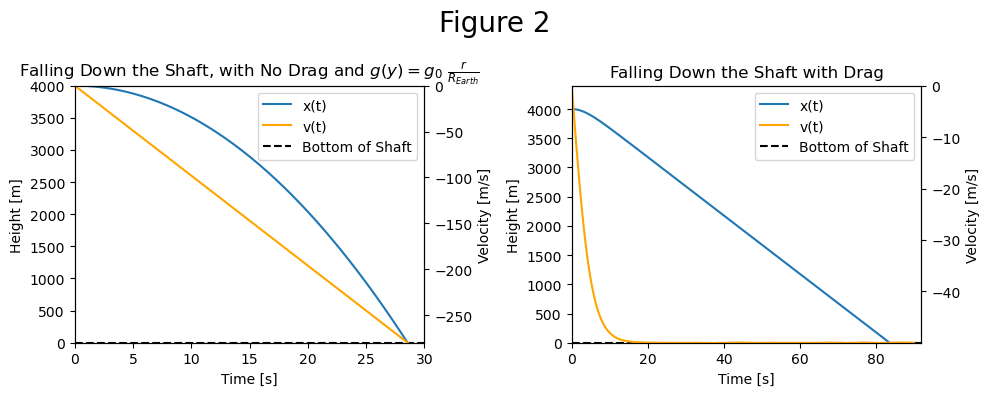

In [3]:
def g(y):
    return g_0*(y+R_earth-4e3)/R_earth

def new_shaft_system(t, z, gamma, alpha):
    y, v = z
    dvdt = -g(y)+alpha*v**gamma
    dydt = v
    return [dydt, dvdt]

def hit_ground(t, z, gamma, alpha):
    y, v = z
    return y


z0 = [4e3,0]
t_span = (0,1.5*np.sqrt(2*y_0/g_0))
t_eval = np.linspace(t_span[0],t_span[1], 300)

sol = solve_ivp(new_shaft_system, t_span=t_span, y0=z0, t_eval=t_eval, events=hit_ground, args=(0,0))

fig2, (ax, ax3) = plt.subplots(1,2, figsize=(10,4))
ax2 = ax.twinx()
l1, = ax.plot(sol.t, sol.y[0], label="x(t)")
l2, = ax2.plot(sol.t, sol.y[1], color='orange', label="v(t)")
l3 = ax.axhline(y=0, color='black', linestyle='--', label="Bottom of Shaft")
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]

ax.set_ylim(0,4e3)
ax.set_xlim(0,30)
ax2.set_ylim(-np.sqrt(2*y_0*g_0),0)
ax2.set_ylabel("Velocity [m/s]")
ax.set_title(r"Falling Down the Shaft, with No Drag and $g(y)=g_0\ \frac{r}{R_{Earth}}$")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Height [m]")

ax.legend(lines, labels)
fig2.suptitle("Figure 2", fontsize=20)


print(f"Dragless Time of Impact with Bottom: {sol.t_events[0][0]:.3f} seconds.")

z0 = [4e3,0]
t_span = (0,90)
t_eval = np.linspace(t_span[0],t_span[1], 500)


sol_drag = solve_ivp(new_shaft_system, t_span=t_span, y0=z0, t_eval=t_eval, events=hit_ground, args=(2,3.924e-03))
print(f"Time to Hit Ground with Drag: {sol_drag.t_events[0][0]:.3f} seconds.")
print(f"Final Velocity: {sol_drag.y_events[0][0,1]:.3f} m/s.")

l1, = ax3.plot(sol_drag.t, sol_drag.y[0], label="x(t)")
ax4 = ax3.twinx()
l2, = ax4.plot(sol_drag.t, sol_drag.y[1], color='orange', label="v(t)")
l3 = ax3.axhline(y=0, color='black', label="Bottom of Shaft", linestyle='--')
ax4.set_ylim(sol_drag.y_events[0][0,1],0)
ax3.set_xlim(0,sol_drag.t_events[0]*1.1)
ax3.set_ylim(0,4e3*1.1)
ax3.set_title("Falling Down the Shaft with Drag")
ax3.set_xlabel("Time [s]")
ax3.set_ylabel("Height [m]")
ax4.set_ylabel("Velocity [m/s]")
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels)
fig2.tight_layout()
plt.show()

Incorporating a height-dependent $g$ has very little effect on fall time, affecting only the thousands place. This makes sense, since the 4 km mineshaft is much shorter than the radius of the Earth. 

However, incorporating drag increases the fall time dramatically. This makes sense because the natural trajectory of the ball has it hit terminal velocity very early on, as can be seen by the flattening velocity curve on the right, meaning drag quickly becomes the dominant force. 

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




Time to Hit Bottom w/o Drag: 28.558
Time to Hit Wall w/o Drag: 21.887
Time to Hit Bottom with Drag: 83.543
Time to Hit Wall with Drag: 29.547


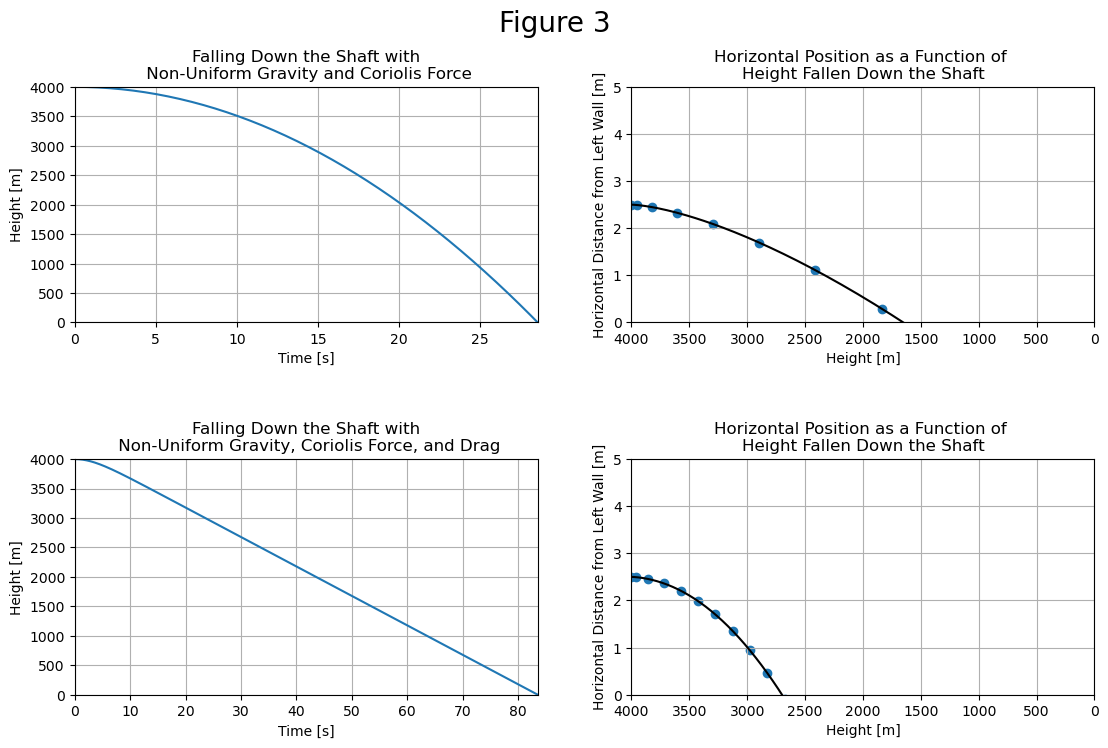

In [4]:
width = 5

def coriolis_system(t, z, gamma, alpha, Omega):
    y, x, v_y, v_x = z
    dv_ydt = -g(y)+alpha*v_y**gamma - 2*Omega*v_x #m omitted because F=ma
    dv_xdt = 2*Omega*v_y #m omitted because F=ma
    dydt = v_y  
    dxdt = v_x
    return [dydt, dxdt, dv_ydt, dv_xdt]

def hit_ground(t, z, gamma, alpha, Omega):
    y, x, v_y, v_x = z
    return y

def hit_left_wall(t, z, gamma, alpha, Omega):
    y, x, v_y, v_x = z
    return x

def hit_right_wall(t, z, gamma, alpha, Omega):
    y, x, v_y, v_x = z
    return width-x

z0 = [4e3, width/2, 0, 0]
t_span = (0,120)
t_eval = np.linspace(t_span[0],t_span[1], 500)
Omega = 2*np.pi/86164 #86164 is the number of seconds in a sidereal day
sol_cor = solve_ivp(coriolis_system, t_span=t_span, y0=z0, t_eval=t_eval, events=(hit_ground, hit_left_wall, hit_right_wall), args=(2, 0, Omega), dense_output=True)

fig3, ((ax5, ax6), (ax7, ax8)) = plt.subplots(2,2, figsize=(12,8))
ax5.plot(sol_cor.t, sol_cor.y[0])
ax5.set_xlim(0,sol_cor.t_events[0])
ax5.set_ylim(0,4e3)
ax5.set_xlabel("Time [s]")
ax5.set_ylabel("Height [m]")
ax5.set_title("Falling Down the Shaft with\n Non-Uniform Gravity and Coriolis Force")
ax6.plot(sol_cor.y[0], sol_cor.y[1], color='black')
ax6.set_xlim(0,4e3)
ax6.set_ylim(0, 5)
ax6.invert_xaxis()
ax6.set_xlabel("Height [m]")
ax6.set_ylabel("Horizontal Distance from Left Wall [m]")
ax6.set_title("Horizontal Position as a Function of \nHeight Fallen Down the Shaft")
ax6.grid()
ax5.grid()

sample_t = np.arange(t_span[0], t_span[1], 3)
sample_y, sample_x, sample_v_y, sample_v_x = sol_cor.sol(sample_t)
ax6.scatter(sample_y, sample_x)


print(f"Time to Hit Bottom w/o Drag: {sol_cor.t_events[0][0]:.3f}")
print(f"Time to Hit Wall w/o Drag: {sol_cor.t_events[1][0]:.3f}")

sol_cor_drag = solve_ivp(coriolis_system, t_span=t_span, y0=z0, t_eval=t_eval, events=(hit_ground, hit_left_wall, hit_right_wall), args=(2, 3.924e-03, Omega), dense_output=True)

ax7.plot(sol_cor_drag.t, sol_cor_drag.y[0])
ax7.set_xlim(0,sol_cor_drag.t_events[0])
ax7.set_ylim(0,4e3)
ax7.set_xlabel("Time [s]")
ax7.set_ylabel("Height [m]")
ax7.set_title("Falling Down the Shaft with\n Non-Uniform Gravity, Coriolis Force, and Drag")
ax8.plot(sol_cor_drag.y[0], sol_cor_drag.y[1], color='black')
ax8.set_xlim(0,4e3)
ax8.set_ylim(0, 5)
ax8.invert_xaxis()
ax8.set_xlabel("Height [m]")
ax8.set_ylabel("Horizontal Distance from Left Wall [m]")
ax8.set_title("Horizontal Position as a Function of \nHeight Fallen Down the Shaft")
ax8.grid()
ax7.grid()

sample_y_drag, sample_x_drag, sample_v_y_drag, sample_v_x_drag = sol_cor_drag.sol(sample_t)
ax8.scatter(sample_y_drag, sample_x_drag)

print(f"Time to Hit Bottom with Drag: {sol_cor_drag.t_events[0][0]:.3f}")
print(f"Time to Hit Wall with Drag: {sol_cor_drag.t_events[1][0]:.3f}")

fig3.tight_layout(pad=4)
fig3.suptitle("Figure 3", fontsize=20)
plt.show()



As you can see in the print statements and graphs above, in the dragless case, the mass hits the wall before it hits the bottom of the well.
When we introduce drag, the mass falls vertically much slower, and so takes a much longer time to hit the bottom of the well, but its time to hit the side of the well only increases slightly, since that motion is much farther from the terminal speed. Since the latter happens first, the system is largely unaffected by the introduction of drag. Another interesting detail is that we can see that while the equal time step dots become increasingly sparse on the top graph as time goes on, they stay roughly equally spaced on the bottom, indicating that the mass with drag is undergoing far less acceleration. 

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





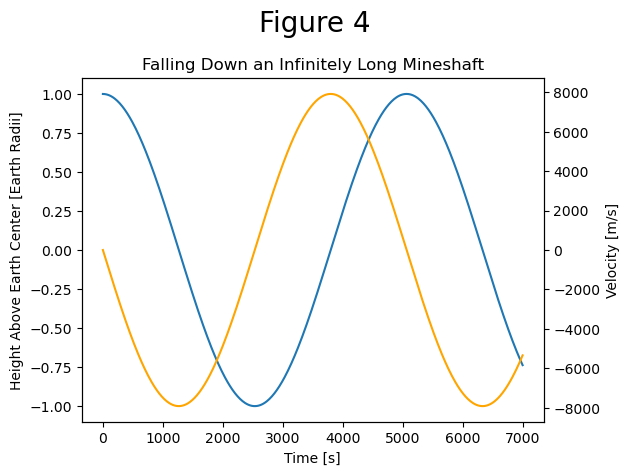

Mass reaches the other side of the Earth at 2532.612 seconds.
Mass passes the center of the Earth at speed 7910.760 m/s at 1266.473 seconds.


In [5]:
def g_inf(y):
    return g_0*y/R_earth #changing to coordinates where y=0 is the center of the earth
    
def inf_shaft_system(t, z):
    y, v = z
    dvdt = -g_inf(y)
    dydt = v
    return [dydt, dvdt]

def other_side(t, z):
    y, v = z
    return v
other_side.direction = 1

def center(t, z):
    y, v = z
    return y

z0 = [R_earth, 0]
t_span = (0,7e3)
t_eval = np.linspace(t_span[0],t_span[1], 500)

sol_inf = solve_ivp(inf_shaft_system, t_span=t_span, y0=z0, t_eval=t_eval, events=(other_side, center))

fig4, ax9 = plt.subplots()
ax9.plot(sol_inf.t, sol_inf.y[0]/R_earth)  #plotting in Earth radii
ax9.set_xlabel("Time [s]")
ax9.set_ylabel("Height Above Earth Center [Earth Radii]")
ax9.set_title("Falling Down an Infinitely Long Mineshaft")
twin_ax9 = ax9.twinx()
twin_ax9.plot(sol_inf.t, sol_inf.y[1], color='orange')
twin_ax9.set_ylabel("Velocity [m/s]")

fig4.suptitle("Figure 4", fontsize=20)
fig4.tight_layout()  
plt.show()

print(f"Mass reaches the other side of the Earth at {sol_inf.t_events[0][0]:.3f} seconds.")
center_vel = sol_inf.y_events[1][0][1]    #[1] to clarify center event, [0] to clarify the first occurrence, and [1] to clarify v instead of y
print(f"Mass passes the center of the Earth at speed {np.abs(center_vel):.3f} m/s at {sol_inf.t_events[1][0]:.3f} seconds.")



In the graph, we can see an oscillation, as we would expect. It begins at rest, falling towards the center of the Earth with increasing velocity, until it zooms past, and is then pulled back towards the core by the Earth's gravity. This oscillation has amplitude equal to the radius of the Earth, which is in line with conservation of energy since that's where the mass started, and has a period of (very roughly) 5000 seconds.

As detailed in the print statements above, it takes around 2532 seconds to get to the other side of the Earth, and it takes it approximately 1266 seconds to get to the center of the Earth.

If we solve for $v$ in the centripetal-gravity equation given above, we get $v=\sqrt\frac{GM}{R}$.\
The orbital period is given by $\frac{2\pi R}{v}=2\pi R \sqrt\frac{R}{GM}\approx 5069.37$ s (see print statement below.)\
I've also printed this period divided by 4: it's almost exactly 4 times the value we got for the time to fall to the center of the Earth. This makes sense, since you make four trips to and from the center throughout a period: once to the center, once to the other side, once back to the center, and once back to the original position.

In [6]:
period = 2*np.pi*R_earth*np.sqrt(R_earth / (G*M_earth))
print(period)
print(period/4)

5069.371199675785
1267.3427999189462


## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

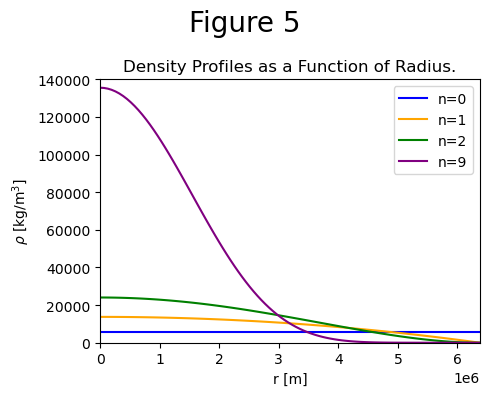

In [7]:
from scipy.integrate import quad

def rho(r, n):
    return (1 - r**2 / R_earth**2)**n

def norm_rho(n):
    func = lambda r: rho(r, n)
    mass_integral, _ = quad(lambda r: func(r) * 4 * np.pi * r**2, 0, R_earth)
    return lambda r: func(r) * (M_earth / mass_integral)

xarr = np.linspace(1e-5, R_earth, 100)
nlist = [0, 1, 2, 9]

fig5, ax = plt.subplots(figsize=(5, 4))
colors = ['blue', 'orange', 'green', 'purple']

for n_ind, n in enumerate(nlist):
    norm_func = norm_rho(n)
    yarr = norm_func(xarr)
    ax.plot(xarr, yarr, color=colors[n_ind], label=f"n={n}")
    ax.set_xlim(0, R_earth)
    ax.set_ylim(0, 140000)
    ax.set_title("Density Profiles as a Function of Radius.")
    ax.set_xlabel("r [m]")
    ax.set_ylabel(r"$\rho$ [kg/m$^3$]")

fig5.suptitle("Figure 5", fontsize=20)
ax.legend()
fig5.tight_layout()

plt.show()

### Part 5, Section B (Forces)

For the force profile, we invoke the shell theorem. That is, if we draw a spherical Gaussian surface at radius $r$, only the enclosed mass will have an effect due to the spherical symmetry of the density profile. Therefore,
$$\oint \vec{g}\cdot d\mathbf{l} = 4\pi G m_{encl}$$
$$\oint \vec{g}\cdot d\mathbf{l} = 4\pi r^2 |\vec{g}|\Rightarrow \vec{g}=-\mathbf{\hat r} \frac{Gm_{encl}}{r^2}$$
I chose $4\pi G$ for the constant in our version of Gauss's Law here so that when we take $m_{encl}$ to be a constant (corresponding to a point mass) we would recover Newton's law of gravitation. \
Below, I plot the magnitude of the force felt at a given radius, but it should be recognized that the force always points inwards. 

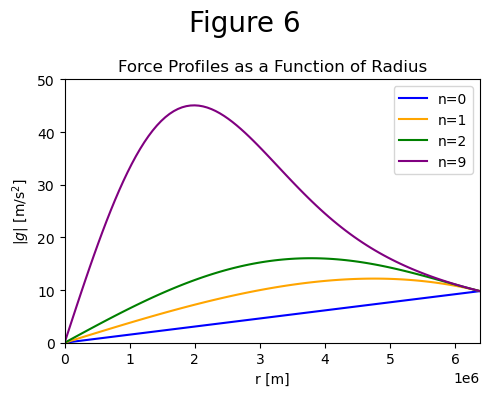

In [8]:
def g(n):
    norm_func = norm_rho(n)
    m_encl = lambda r: quad(lambda x: norm_func(x) * 4 * np.pi * x**2, 0, r)[0]     
    return lambda r: G * m_encl(r) / r**2    #again, the mass of the test mass is omitted because it doesn't affect the physics here

fig6, ax = plt.subplots(figsize=(5, 4))

for n_ind, n in enumerate(nlist):
    yarr = [g(n)(r) for r in xarr]  
    ax.plot(xarr, yarr, color=colors[n_ind], label=f"n={n}")
    ax.set_title("Force Profiles as a Function of Radius")
    ax.set_xlabel("r [m]")
    ax.set_ylabel(r"$|g|$ [m/s$^2$]")
    ax.set_xlim(0,R_earth)
    ax.set_ylim(0,50)


fig6.suptitle("Figure 6", fontsize=20)
ax.legend()
fig6.tight_layout()

plt.show()

### Part 5, Section C (Equations of Motion)

n=0 reaches the center of the Earth at 1267.241 seconds.
n=1 reaches the center of the Earth at 1096.891 seconds.
n=2 reaches the center of the Earth at 1035.139 seconds.
n=9 reaches the center of the Earth at 943.875 seconds.


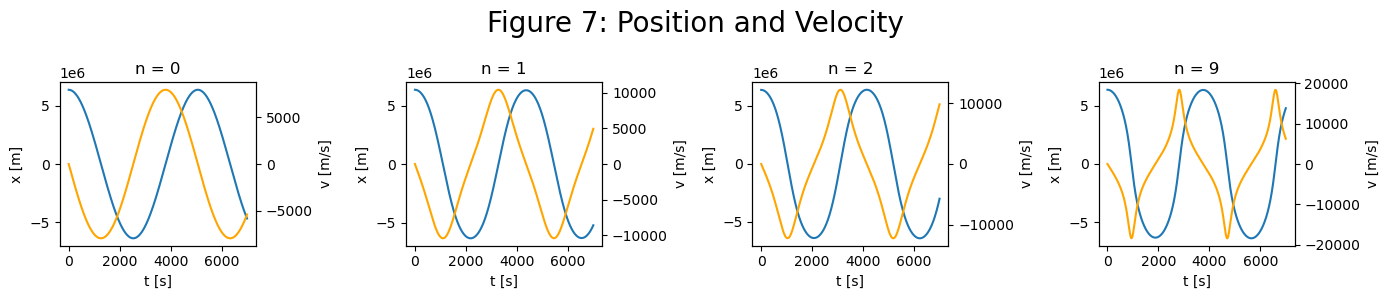

In [9]:
def non_uni_system(t, z, n):
    y, v = z
    dydt = v
    dvdt = -g(n)(y)
    return [dydt, dvdt]

def center(t, z, n):
    y, v = z
    return y

z0 = [R_earth, 0]
t_span = (0,7e3)
t_eval = np.linspace(t_span[0],t_span[1], 500)

fig7, axes3 = plt.subplots(1, 4, figsize=(14, 3))

for n, ax in zip(nlist, axes3):
    sol_non_uni = solve_ivp(non_uni_system, t_span=t_span, y0=z0, t_eval=t_eval, args=(n,), events=center)
    ax.plot(sol_non_uni.t, sol_non_uni.y[0])
    twin_ax = ax.twinx()
    twin_ax.plot(sol_non_uni.t, sol_non_uni.y[1], color='orange')
    ax.set_title(f"n = {n}")
    ax.set_xlabel("t [s]")
    ax.set_ylabel("x [m]")
    twin_ax.set_ylabel("v [m/s]")
    print(f"n={n} reaches the center of the Earth at {sol_non_uni.t_events[0][0]:.3f} seconds.")


fig7.suptitle("Figure 7: Position and Velocity", fontsize=20)
fig7.tight_layout()

plt.show()

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


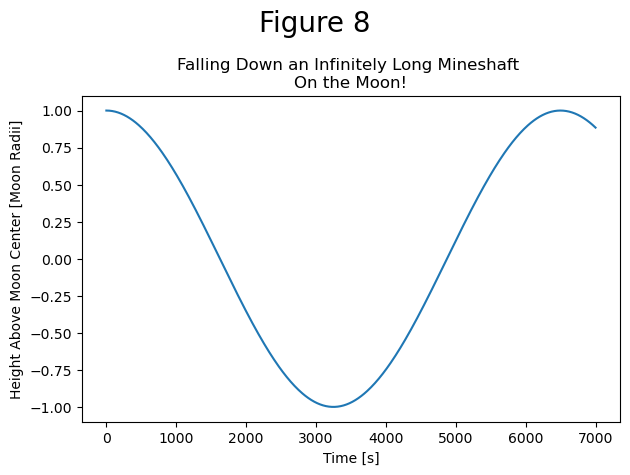

Mass reaches the other side of the Moon at 3249.651 seconds.
Mass passes the center of the Moon at speed 1679.949 m/s at 1624.906 seconds.


In [10]:
def moon_g_inf(y):
    g_surface = G*M_moon/R_moon**2
    return g_surface*y/R_moon
    
def moon_shaft_system(t, z):
    y, v = z
    dvdt = -moon_g_inf(y)
    dydt = v
    return [dydt, dvdt]

def other_side(t, z):
    y, v = z
    return v
other_side.direction = 1

def center(t, z):
    y, v = z
    return y

z0 = [R_moon, 0]
t_span = (0,7e3)
t_eval = np.linspace(t_span[0],t_span[1], 500)

sol_moon = solve_ivp(moon_shaft_system, t_span=t_span, y0=z0, t_eval=t_eval, events=(other_side, center))

fig8, ax = plt.subplots()
ax.plot(sol_moon.t, sol_moon.y[0]/R_moon)  #plotting in Moon radii
ax.set_xlabel("Time [s]")
ax.set_ylabel("Height Above Moon Center [Moon Radii]")
ax.set_title("Falling Down an Infinitely Long Mineshaft \nOn the Moon!")

fig8.suptitle("Figure 8", fontsize=20)
fig8.tight_layout()  
plt.show()

print(f"Mass reaches the other side of the Moon at {sol_moon.t_events[0][0]:.3f} seconds.")
center_vel = sol_moon.y_events[1][0][1]
print(f"Mass passes the center of the Moon at speed {np.abs(center_vel):.3f} m/s at {sol_moon.t_events[1][0]:.3f} seconds.")

In [11]:
rho_moon = M_moon/(4*np.pi*R_moon**3/3)
print(f"The density of the Moon is given by its mass divided by its volume, yielding {rho_moon:.3f} kg/m^3.")

The density of the Moon is given by its mass divided by its volume, yielding 3341.754 kg/m^3.


If we assume uniform density, and thus acceleration $\vec{g}=-\mathbf{\hat r} g_{moon}\frac{y}{R_moon}$, we have
$$y''+\frac{g_{moon}}{R_{moon}}y=0$$
which is the harmonic oscillator with frequency $\omega\equiv\sqrt\frac{g_{moon}}{R_{moon}}$. This has solution
$$y(t)=y_0\cos(\omega t)\Rightarrow t_{center}=\frac{\pi}{2\omega}=\frac{\pi}{2}\sqrt\frac{R_{moon}}{g_{moon}}$$
But 
$$g_{moon}=\frac{GM_{moon}}{R_{moon}^2}=\frac{1}{3}4\pi GR_{moon}\rho_{moon} \Rightarrow \frac{\pi}{2}\sqrt\frac{R_{moon}}{g_{moon}}=\boxed{\sqrt{\frac{3\pi}{16G}\frac{1}{\rho_{moon}}}.}$$
Therefore, our relation is that fall time goes as $\rho^{-1/2}$. 

In [12]:
print(f"Plugging in our density value from before, we have a fall time to the center of the Moon of {np.sqrt(3*np.pi/(16*G*rho_moon)):.3f} seconds.")

Plugging in our density value from before, we have a fall time to the center of the Moon of 1625.120 seconds.


This matches quite nicely with the plot given above.
The value for the Earth is approximately 1266.47 seconds, which fits our data, since using $\rho_{Earth}\approx 5513$ kg/m$^3$, \
$\sqrt{\frac{3\pi}{16G}\frac{1}{\rho_{Earth}}}\approx1265.66$ seconds. 


## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

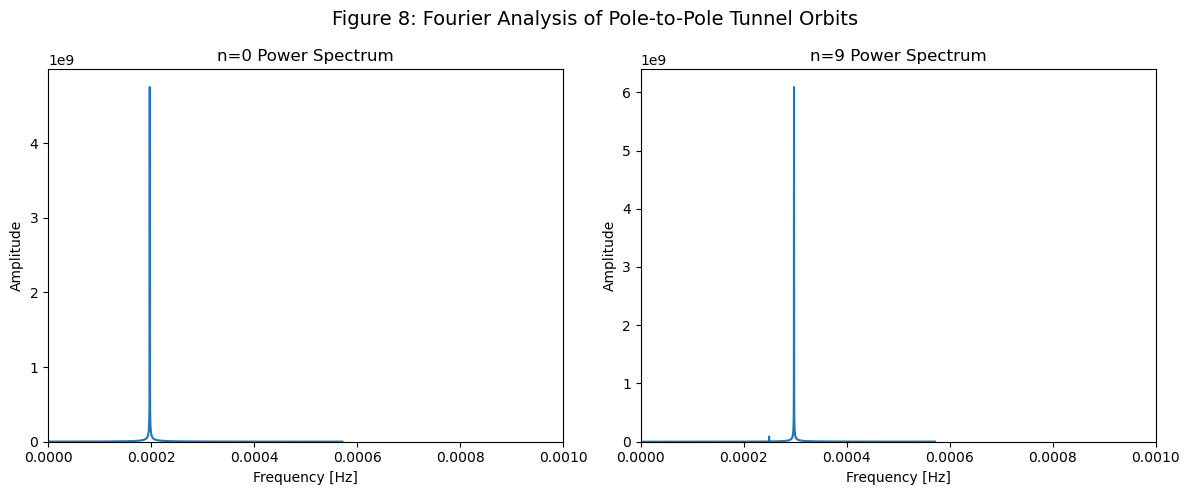

n=0 peaks at frequency 1.9726e-04 Hz.
This corresponds to a period of 5069.42441 seconds.
n=9 peaks at frequency 2.9782e-04 Hz.
This corresponds to a period of 3357.73387 seconds.


In [13]:
t_span = (0, 7e6)
t_eval = np.linspace(t_span[0], t_span[1], 8000)
sol_0 = solve_ivp(non_uni_system, t_span=t_span, y0=z0, t_eval=t_eval, args=(0,))
sol_9 = solve_ivp(non_uni_system, t_span=t_span, y0=z0, t_eval=t_eval, args=(9,), rtol=1e-10, atol=1e-10)
dt = t_eval[1] - t_eval[0]

sol_0_fft = np.fft.rfft(sol_0.y[0])
freqs_0 = np.fft.rfftfreq(len(sol_0.y[0]), d=dt)
sol_9_fft = np.fft.rfft(sol_9.y[0])
freqs_9 = np.fft.rfftfreq(len(sol_9.y[0]), d=dt)

fig9, (ax10, ax11) = plt.subplots(1, 2, figsize=(12, 5))
ax10.plot(freqs_0, np.abs(sol_0_fft))
ax10.set_xlim(0, 0.001)
ax10.set_ylim(0)
ax10.set_xlabel('Frequency [Hz]')
ax10.set_ylabel('Amplitude')
ax10.set_title('n=0 Power Spectrum')

ax11.plot(freqs_9, np.abs(sol_9_fft))
ax11.set_xlim(0, 0.001)
ax11.set_ylim(0)
ax11.set_xlabel('Frequency [Hz]')
ax11.set_ylabel('Amplitude')
ax11.set_title('n=9 Power Spectrum')

fig9.suptitle('Figure 8: Fourier Analysis of Pole-to-Pole Tunnel Orbits', fontsize=14)
fig9.tight_layout()
plt.show()

pos_0 = freqs_0 > 0
pos_9 = freqs_9 > 0
freqs_peak_0 = freqs_0[pos_0][np.argmax(np.abs(sol_0_fft[pos_0]))]
freqs_peak_9 = freqs_9[pos_9][np.argmax(np.abs(sol_9_fft[pos_9]))]

print(f"n=0 peaks at frequency {freqs_peak_0:.4e} Hz.")
print(f"This corresponds to a period of {1/freqs_peak_0:.5f} seconds.")
print(f"n=9 peaks at frequency {freqs_peak_9:.4e} Hz.")
print(f"This corresponds to a period of {1/freqs_peak_9:.5f} seconds.")

For $n=0$, the frequency is quite simple. It consists essentially of a single dominant frequency corresponding to a period of about 5069.4 seconds, which is almost exactly 4 times the period for $n=0$ we measured in Part 5. This is what we would expect, since a single orbital period consists of traveling to the center, going that same distance to the other side, and coming all the way back to the start position.

On the other hand, the $n=9$ spectrum has several dominant frequencies, but the frequency corresponding to a period of around 3357 seconds dominates. Again, this is around 4 times the time the test mass in the $n=9$ situation took to fall to the center of the Earth, reinforcing our theory of how these frequency ought to be formed based on the time-domain physics. 

We interpret the multiple frequencies present in the $n=9$ spectrum as being related to the fact that unlike the $n=0$ case, the $n=9$ distribution does not induce simple harmonic motion. Simple harmonic motion (governed by a linear restoring force, which we find in the $n=0$ case in $g_0\frac{y}{R_{Earth}}$) is well-known to undergo motion of a single oscillatory frequency, which is the single dominating frequency we see. This is clearly different than the situation in $n=9$, where the restoring force is highly nonlinear, and so the spectrum must pick up additional frequencies to describe the more sophisticated behavior.